In [53]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from datetime import datetime

In [54]:
df = pd.read_csv("pendulum_trajectories.csv")

In [55]:
df["theta"] = (df["theta"] + np.pi) % (2 * np.pi) - np.pi
df["theta_next"] = (df["theta_next"] + np.pi) % (2 * np.pi) - np.pi

In [56]:
train = df[df["split"] == "train"]

In [57]:
class SimDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx, :]
    
dataset = SimDataset(train[["theta", "omega"]].values, train[["theta_next", "omega_next"]].values)

loader = DataLoader(dataset, batch_size=32)

In [58]:
class HNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.mlp(x)

In [59]:
dt = 0.01

def loss_fn(x, y, H):
    # compute dH/dtheta and dH/domega via autograd
    dH = torch.autograd.grad(H.sum(), x, create_graph=True)[0]

    dtheta_dt_hat = dH[:, 1]    # dH/domega
    domega_dt_hat = -dH[:, 0]   # -dH/dtheta

    # finite difference targets from data
    dtheta_dt = (y[:, 0] - x[:, 0].detach()) / dt
    domega_dt = (y[:, 1] - x[:, 1].detach()) / dt

    theta_loss = nn.functional.mse_loss(dtheta_dt_hat, dtheta_dt)
    omega_loss = nn.functional.mse_loss(domega_dt_hat, domega_dt)

    loss = theta_loss + omega_loss
    return loss, theta_loss, omega_loss

In [60]:
hidden_dim = 6

model = HNN(2, hidden_dim, 1)

lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [61]:
epochs = 200

for epoch in range(epochs):
    total_loss = 0
    total_theta = 0
    total_omega = 0

    for x, y in loader:
        optimizer.zero_grad()

        x = x.to(torch.float32)
        y = y.to(torch.float32)
        x.requires_grad_(True)

        H = model(x) 
        loss, theta_loss, omega_loss = loss_fn(x, y, H)
        total_loss += loss.item()
        total_theta += theta_loss.item()
        total_omega += omega_loss.item()

        loss.backward()
        optimizer.step()

    print(
        f"Epoch: {epoch+1} | Loss: {total_loss / len(loader):.2f} | Theta: {total_theta / len(loader):.2f} | Omega: {total_omega / len(loader):.2f}"
    )

Epoch: 1 | Loss: 410.59 | Theta: 354.04 | Omega: 56.55
Epoch: 2 | Loss: 409.59 | Theta: 353.77 | Omega: 55.82
Epoch: 3 | Loss: 403.20 | Theta: 353.57 | Omega: 49.63
Epoch: 4 | Loss: 389.62 | Theta: 353.37 | Omega: 36.25
Epoch: 5 | Loss: 378.33 | Theta: 353.16 | Omega: 25.18
Epoch: 6 | Loss: 371.15 | Theta: 353.02 | Omega: 18.14
Epoch: 7 | Loss: 366.60 | Theta: 352.84 | Omega: 13.76
Epoch: 8 | Loss: 363.46 | Theta: 352.57 | Omega: 10.88
Epoch: 9 | Loss: 361.01 | Theta: 352.17 | Omega: 8.84
Epoch: 10 | Loss: 358.90 | Theta: 351.61 | Omega: 7.29
Epoch: 11 | Loss: 357.02 | Theta: 350.98 | Omega: 6.04
Epoch: 12 | Loss: 355.46 | Theta: 350.39 | Omega: 5.07
Epoch: 13 | Loss: 354.15 | Theta: 349.79 | Omega: 4.36
Epoch: 14 | Loss: 353.05 | Theta: 349.21 | Omega: 3.84
Epoch: 15 | Loss: 352.10 | Theta: 348.66 | Omega: 3.44
Epoch: 16 | Loss: 351.28 | Theta: 348.15 | Omega: 3.14
Epoch: 17 | Loss: 350.57 | Theta: 347.67 | Omega: 2.90
Epoch: 18 | Loss: 349.93 | Theta: 347.22 | Omega: 2.71
Epoch: 19 |

In [62]:
model.eval()
test = df[df["split"] == "test"]

x_test = torch.tensor(test[["theta", "omega"]].values, dtype=torch.float32)
y_test = torch.tensor(test[["theta_next", "omega_next"]].values, dtype=torch.float32)

x_test.requires_grad_(True)
H_test = model(x_test)

dH = torch.autograd.grad(H_test.sum(), x_test)[0]
dtheta_dt_hat = dH[:, 1]
domega_dt_hat = -dH[:, 0]

dtheta_dt = (y_test[:, 0] - x_test[:, 0].detach()) / dt
domega_dt = (y_test[:, 1] - x_test[:, 1].detach()) / dt

theta_mse = nn.functional.mse_loss(dtheta_dt_hat, dtheta_dt)
omega_mse = nn.functional.mse_loss(domega_dt_hat, domega_dt)
test_loss = theta_mse + omega_mse

print(f"Test MSE: {test_loss.item():.6f}")
print(f"Theta MSE: {theta_mse.item():.6f} | Omega MSE: {omega_mse.item():.6f}")

Test MSE: 0.654808
Theta MSE: 0.156483 | Omega MSE: 0.498324


In [63]:
theta0 = 1.0  # radians
omega0 = 0.0  # rad/s
n_steps = 1000

rows = []
state = torch.tensor([[theta0, omega0]], dtype=torch.float32)

model.eval()
for _ in range(n_steps):
    state.requires_grad_(True)
    H = model(state)

    dH = torch.autograd.grad(H.sum(), state)[0]
    dtheta_dt = dH[0, 1].item()
    domega_dt = -dH[0, 0].item()

    # Euler integration to get next state
    theta_next = state[0, 0].item() + dtheta_dt * dt
    omega_next = state[0, 1].item() + domega_dt * dt
    theta_next = (theta_next + np.pi) % (2 * np.pi) - np.pi

    rows.append([theta_next, omega_next])
    state = torch.tensor([[theta_next, omega_next]], dtype=torch.float32)

arr = np.array(rows)
np.save("hnn_trajectory.npy", arr)
print(f"Saved {len(arr)} steps to hnn_trajectory.npy")

Saved 1000 steps to hnn_trajectory.npy


In [64]:
now = datetime.now()
date_time = now.strftime("%m-%d-%H:%M:%S")

torch.save(model.state_dict(), f"hnn_models/pinn-{date_time}-{hidden_dim}hdim.pth")

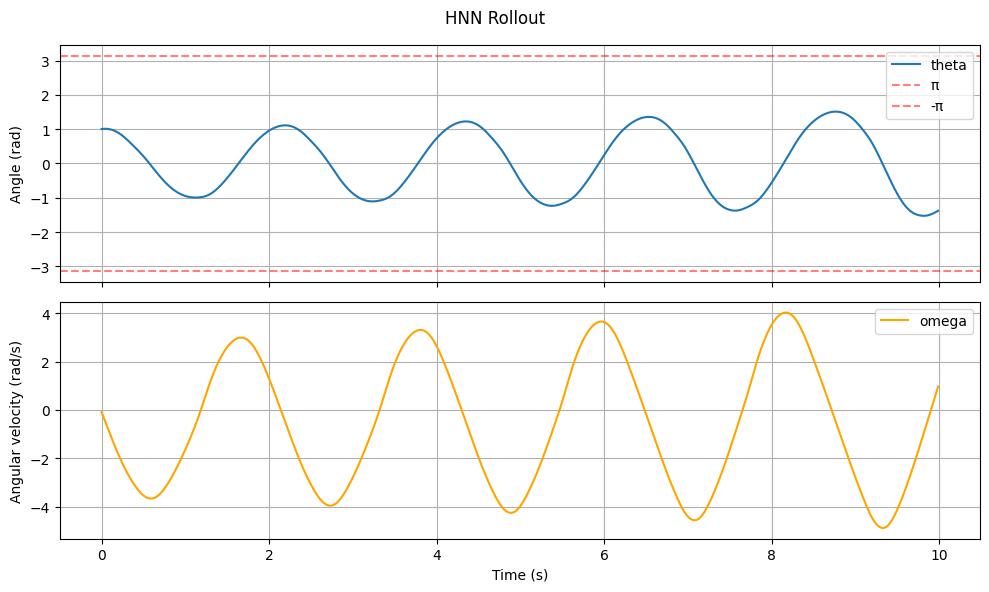

In [65]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.load("hnn_trajectory.npy")
t = np.arange(len(arr)) * 0.01  # timestep = 0.01

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t, arr[:, 0], label="theta")
ax1.set_ylabel("Angle (rad)")
ax1.axhline(np.pi, color="r", linestyle="--", alpha=0.5, label="π")
ax1.axhline(-np.pi, color="r", linestyle="--", alpha=0.5, label="-π")
ax1.legend()
ax1.grid(True)

ax2.plot(t, arr[:, 1], label="omega", color="orange")
ax2.set_ylabel("Angular velocity (rad/s)")
ax2.set_xlabel("Time (s)")
ax2.legend()
ax2.grid(True)

plt.suptitle("HNN Rollout")
plt.tight_layout()
plt.show()